# 06: Amazon Reviews 2023 (Electronics) als Stichprobe zur externen Robustheitsprüfung

**Ziel:** Anhand einer unabhängigen Stichprobe aus einer anderen Produktkategorie und Plattformdomäne (Amazon Electronics statt Women's Clothing E Commerce) wird geprüft, ob sich die zentralen Befunde aus `04_Regression.ipynb`, insbesondere der in H3 untersuchte Zusammenhang zwischen Sentiment und Rating, ausserhalb des ursprünglichen Datensatzes in vergleichbarer Form zeigen.

**Datensatz:** [`McAuley-Lab/Amazon-Reviews-2023`](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023) mit insgesamt rund 43,9 Millionen Reviews über verschiedene Produktkategorien. Da bereits die einzelne Kategorie **Electronics** mehrere Millionen Reviews umfasst, wird nicht der vollständige Datensatz heruntergeladen. Stattdessen wird mittels Streaming (`streaming=True`) direkt eine Stichprobe von 25'000 Reviews gezogen.

**Hinweis zum Laden:** Der offizielle Loader des Datensatz Repositories verwendet ein Python Ladeskript (`Amazon-Reviews-2023.py`). Aktuelle Versionen der `datasets` Bibliothek ab Version 4.0 unterstützen solche Dataset Skripte nicht mehr und führen beim entsprechenden Ladeversuch zu einem `RuntimeError`. Die Rohdaten werden jedoch zusätzlich direkt als JSON Lines Datei für jede Produktkategorie bereitgestellt. Für die vorliegende Analyse wird daher `raw/review_categories/Electronics.jsonl` unmittelbar als generisches `"json"` Dataset geladen. Diese Datei enthält die für die Analyse benötigten Reviewdaten der Kategorie Electronics und ist von der separaten Metadatenvariante `raw_meta_Electronics` zu unterscheiden.

In [1]:
import pandas as pd
from pathlib import Path
from datasets import load_dataset

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

OUT_FILE = RAW_DIR / "amazon_electronics_sample.csv"
SEED = 42
SAMPLE_SIZE = 25_000
BUFFER_SIZE = 200_000  # Begründung siehe Markdown unten

## Streaming-Datensatz laden und Stichprobe ziehen

**Zur Puffergrösse:** Eine Stichprobenprüfung der ersten 20'000 Zeilen zeigte, dass die Rohdatei nach `user_id` gruppiert ist und aufeinanderfolgende Reviews derselben Person enthält, teilweise mehr als 500 Reviews am Stück. Bei einem zu kleinen Shuffle Puffer könnte die gezogene Stichprobe daher überproportional von wenigen Personen mit besonders vielen Reviews geprägt sein. Mit `BUFFER_SIZE = 200_000` erfolgt die Durchmischung über einen deutlich grösseren Bereich und damit über wesentlich mehr Personen hinweg. Bei einer gemessenen Lesegeschwindigkeit von rund 9'000 Zeilen pro Sekunde dauert das Einlesen von Puffer und Stichprobe zusammen etwa 25 bis 30 Sekunden. Gleichzeitig bleibt die gewählte Puffergrösse deutlich unter der Gesamtzahl der Reviews in der Kategorie Electronics.

In [3]:
electronics_stream = load_dataset(
    "json",
    data_files="hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/Electronics.jsonl",
    split="train",
    streaming=True,
)

electronics_sample_stream = electronics_stream.shuffle(seed=SEED, buffer_size=BUFFER_SIZE).take(SAMPLE_SIZE)
electronics_sample_stream

IterableDataset({
    features: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'],
    num_shards: 1
})

In [4]:
records = [
    {"rating": row["rating"], "title": row["title"], "text": row["text"]}
    for row in electronics_sample_stream
]
amazon_df = pd.DataFrame(records)
amazon_df.shape

(25000, 3)

## Speichern

In [5]:
amazon_df.to_csv(OUT_FILE, index=False)
OUT_FILE

PosixPath('/Users/laraeibel/Desktop/Bachelorarbeit_Python/data/raw/amazon_electronics_sample.csv')

## Kurze Übersicht

In [6]:
print(f"Anzahl Zeilen: {len(amazon_df)}")

rating_dist = amazon_df["rating"].value_counts(normalize=True).sort_index()
print("\nVerteilung von rating:")
print(rating_dist)

Anzahl Zeilen: 25000

Verteilung von rating:
rating
1.0    0.08236
2.0    0.04376
3.0    0.07052
4.0    0.14632
5.0    0.65704
Name: proportion, dtype: float64


In [7]:
missing_text = amazon_df["text"].isna() | (amazon_df["text"].astype(str).str.strip() == "")
n_missing = missing_text.sum()
print(f"Fehlende/leere Reviewtexte: {n_missing} von {len(amazon_df)} ({n_missing / len(amazon_df):.2%})")

Fehlende/leere Reviewtexte: 3 von 25000 (0.01%)


In [8]:
amazon_df.head()

,rating,title,text
0,5.0,High quality vintage style case...,"Great case! High quality, sturdy. Reminds you ..."
1,4.0,I was pleasantly surprised❤️,These have a really good beat to them.
2,5.0,Five Stars,Item works great and was delivered on time
3,5.0,awesome!!,"I wasn't wanting to have to buy a new monitor,..."
4,3.0,Okay,"Very good for the price, but limsy. Doesn't ho..."


## Wie funktioniert der Streaming-Ansatz, und warum ist er hier sinnvoller als der volle Download?

**Funktionsweise:** Mit `streaming=True` wird der Datensatz nicht vollständig heruntergeladen und materialisiert, sondern als iterierbarer Datensatz verarbeitet. Die Daten werden bei Bedarf fortlaufend von der Quelle gelesen, ohne dass zuvor die vollständige Datei lokal gespeichert werden muss. Mit `.shuffle(seed=42, buffer_size=200_000)` wird ein Shuffle Puffer mit bis zu 200'000 Elementen verwendet. Aus diesem Puffer werden Elemente in zufälliger Reihenfolge ausgegeben und während der Iteration durch nachfolgende Elemente aus dem Datenstrom ersetzt. Dadurch wird eine approximative Durchmischung erreicht, ohne den gesamten Datensatz gleichzeitig im Arbeitsspeicher halten zu müssen. Der dafür benötigte Speicher hängt somit primär von der gewählten `BUFFER_SIZE` und nicht von der Gesamtgrösse des Datensatzes ab. Mit `.take(25_000)` wird die Iteration auf 25'000 ausgegebene Reviews begrenzt. Unter dieser Vorgehensweise muss daher nur ein Teil der gesamten Electronics Datei verarbeitet werden, der grössenordnungsmässig durch den Shuffle Puffer und die anschliessend entnommenen Elemente bestimmt wird, anstatt die vollständige Datei einzulesen.

**Warum dieses Vorgehen hier sinnvoller ist als ein vollständiger Download:**

* **Ressourcen:** Die vollständige `Electronics.jsonl` umfasst mehrere Gigabyte. Für eine Stichprobe von 25'000 Reviews wäre ein vollständiger Download mit einem unnötig hohen Bedarf an Bandbreite, Speicherplatz und Rechenzeit verbunden. Bei einem gemessenen Durchsatz von rund 9'000 Zeilen pro Sekunde kann die benötigte Stichprobe mit dem gewählten Streaming Verfahren in weniger als 30 Sekunden erzeugt werden.
* **Reproduzierbarkeit:** Der feste `seed=42` ermöglicht bei unveränderter Datenquelle und identischer Verarbeitung eine reproduzierbare Durchmischung und Stichprobenziehung, ohne dass die vollständige Quelldatei dauerhaft lokal gespeichert werden muss.
* **Praktikabilität für die Robustheitsprüfung:** Für die Untersuchung der Übertragbarkeit der Ergebnisse ist eine ausreichend grosse und angemessen durchmischte Stichprobe ausreichend. Eine Verarbeitung der vollständigen Electronics Kategorie ist für diesen Zweck nicht erforderlich.
**Wichtige methodische Einschränkung:** Der verwendete Shuffle Puffer erzeugt keine uniforme Zufallsstichprobe aus der gesamten Electronics Kategorie. Da die Iteration nach 25'000 ausgegebenen Reviews beendet wird, können nur Reviews berücksichtigt werden, die bis zu diesem Zeitpunkt aus dem Stream in den Shuffle Prozess gelangt sind. Weiter hinten in der Quelldatei liegende Reviews haben somit keine Auswahlwahrscheinlichkeit. Da die Rohdatei zudem nach `user_id` gruppiert ist, wurde mit `BUFFER_SIZE = 200_000` bewusst ein grosser Shuffle Puffer gewählt, um eine breitere Durchmischung über verschiedene Personen zu erreichen und eine übermässige Konzentration auf einzelne Personen mit besonders vielen Reviews zu reduzieren. Die resultierende Stichprobe ist daher methodisch als **Stichprobe aus dem Anfangsbereich des Datenstroms nach gepuffertem Shuffling** und nicht als uniforme Zufallsstichprobe aus der gesamten Electronics Kategorie zu verstehen.

---

# Robustheitsprüfung: Vergleich mit H3 (Sentiment ~ Rating)

Dieser Abschnitt prüft, ob sich der in `04_Regression.ipynb` für H3 festgestellte Zusammenhang zwischen `VADER Compound` und Sternebewertung ausserhalb des ursprünglichen Women's Clothing Datensatzes in vergleichbarer Form zeigt. Hierzu wird eine unabhängige Stichprobe aus der Produktkategorie Electronics herangezogen und damit eine andere Produktkategorie und Plattformdomäne untersucht.


In [3]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import pearsonr, spearmanr

## Datenaufbereitung

In [4]:
amazon_df = pd.read_csv(OUT_FILE)
n_before = len(amazon_df)
n_before

25000

In [5]:
missing_text = amazon_df["text"].isna() | (amazon_df["text"].astype(str).str.strip() == "")
missing_rating = amazon_df["rating"].isna()

amazon_df = amazon_df.loc[~missing_text & ~missing_rating].copy()
n_after = len(amazon_df)

print(f"Zeilen vor Bereinigung: {n_before}")
print(f"Entfernt (fehlender Text): {missing_text.sum()}")
print(f"Entfernt (fehlendes Rating): {missing_rating.sum()}")
print(f"Zeilen nach Bereinigung: {n_after}")

Zeilen vor Bereinigung: 25000
Entfernt (fehlender Text): 8
Entfernt (fehlendes Rating): 0
Zeilen nach Bereinigung: 24992


In [6]:
def normalize_whitespace(text: str) -> str:
    return " ".join(text.split())

# dieselbe Normalisierung wie in 02_Data_Cleaning.ipynb (vor der VADER-Analyse im Hauptdatensatz)
amazon_df["text"] = amazon_df["text"].astype(str).map(normalize_whitespace)
amazon_df["rating"] = amazon_df["rating"].astype(int)

## VADER-Sentimentanalyse

**Konsistenzcheck mit `03_VADER.ipynb`:** Im Hauptdatensatz wird VADER ausschliesslich auf `Review Text` angewendet. `Title` wird nicht in die Sentiment Analysis einbezogen, unter anderem da diese Variable bei knapp 13 Prozent der Reviews fehlt und für die Analyse nicht erforderlich ist, wie in `02_Data_Cleaning.ipynb` beschrieben. Entsprechend wird VADER auch in der Amazon Stichprobe ausschliesslich auf `text` angewendet und nicht auf eine Kombination aus `title` und `text`. Dadurch bleibt die Berechnung der Sentiment Scores zwischen Hauptdatensatz und externer Stichprobe methodisch konsistent und besser vergleichbar.

In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
amazon_scores = amazon_df["text"].apply(analyzer.polarity_scores)
amazon_scores_df = pd.DataFrame(amazon_scores.tolist(), index=amazon_df.index).rename(columns={
    "neg": "vader_negative", "neu": "vader_neutral", "pos": "vader_positive", "compound": "vader_compound",
})
amazon_df = pd.concat([amazon_df, amazon_scores_df], axis=1)
amazon_df[["text", "vader_compound"]].head()

,text,vader_compound
0,"Great case! High quality, sturdy. Reminds you ...",0.9854
1,These have a really good beat to them.,0.4927
2,Item works great and was delivered on time,0.6249
3,"I wasn't wanting to have to buy a new monitor,...",0.9614
4,"Very good for the price, but limsy. Doesn't ho...",0.8072


## J-Shape-Vergleich: Rating-Verteilung Amazon vs. Hauptdatensatz

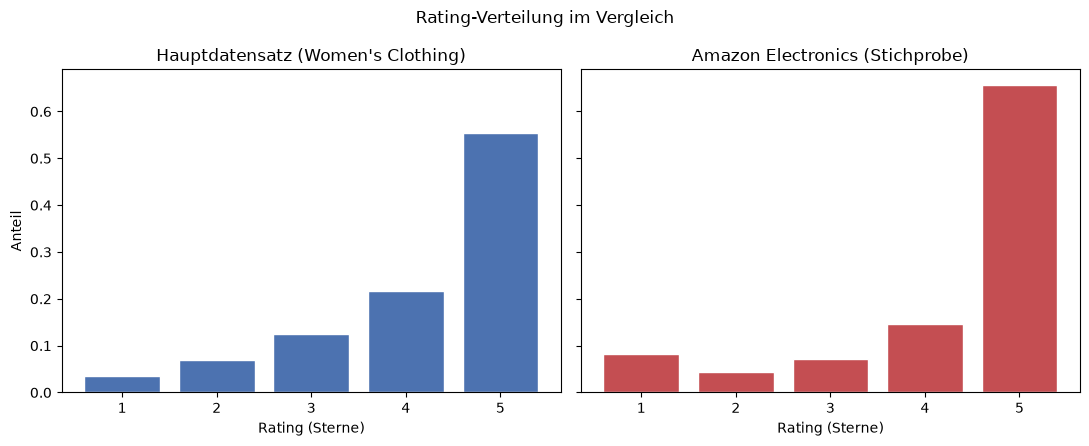

In [8]:
import matplotlib.pyplot as plt

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

main_ratings = pd.read_csv(PROCESSED_DIR / "reviews_vader.csv")["Rating"]

amazon_rating_dist = amazon_df["rating"].value_counts(normalize=True).reindex([1, 2, 3, 4, 5])
main_rating_dist = main_ratings.value_counts(normalize=True).reindex([1, 2, 3, 4, 5])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

axes[0].bar(main_rating_dist.index, main_rating_dist.values, color="#4C72B0", edgecolor="white")
axes[0].set_title("Hauptdatensatz (Women's Clothing)")
axes[0].set_xlabel("Rating (Sterne)")
axes[0].set_ylabel("Anteil")
axes[0].set_xticks([1, 2, 3, 4, 5])

axes[1].bar(amazon_rating_dist.index, amazon_rating_dist.values, color="#C44E52", edgecolor="white")
axes[1].set_title("Amazon Electronics (Stichprobe)")
axes[1].set_xlabel("Rating (Sterne)")
axes[1].set_xticks([1, 2, 3, 4, 5])

fig.suptitle("Rating-Verteilung im Vergleich")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "robustness_rating_distribution_comparison.png", dpi=150)
plt.show()

In [9]:
pd.DataFrame({"Hauptdatensatz": main_rating_dist, "Amazon Electronics": amazon_rating_dist})

,Hauptdatensatz,Amazon Electronics
1,0.036263,0.082346
2,0.068419,0.043774
3,0.124691,0.070543
4,0.216784,0.146207
5,0.553843,0.657130


## Sentiment-Rating-Zusammenhang (Amazon-Stichprobe)

In [10]:
az_ols_linear = smf.ols("vader_compound ~ rating", data=amazon_df).fit()
az_ols_dummy = smf.ols("vader_compound ~ C(rating)", data=amazon_df).fit()

az_ols_comparison = summary_col(
    [az_ols_linear, az_ols_dummy],
    model_names=["Rating linear", "Rating als Dummy"],
    stars=True,
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.4f}",
        "Adj. R2": lambda x: f"{x.rsquared_adj:.4f}",
        "AIC": lambda x: f"{x.aic:.1f}",
    },
)
print(az_ols_comparison)


               Rating linear Rating als Dummy
---------------------------------------------
Intercept      -0.2685***    -0.1007***      
               (0.0092)      (0.0090)        
rating         0.1843***                     
               (0.0021)                      
C(rating)[T.2]               0.1840***       
                             (0.0153)        
C(rating)[T.3]               0.3492***       
                             (0.0133)        
C(rating)[T.4]               0.6571***       
                             (0.0113)        
C(rating)[T.5]               0.7416***       
                             (0.0096)        
R-squared      0.2418        0.2478          
R-squared Adj. 0.2417        0.2477          
AIC            26411.4       26216.8         
Adj. R2        0.2417        0.2477          
N              24992         24992           
R2             0.2418        0.2478          
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [11]:
y_az = pd.Categorical(amazon_df["rating"], categories=[1, 2, 3, 4, 5], ordered=True)
X_az = amazon_df[["vader_compound"]].rename(columns={"vader_compound": "VADER_Compound"}).astype(float)

ordinal_az = OrderedModel(y_az, X_az, distr="logit")
res_az = ordinal_az.fit(method="bfgs", disp=False, maxiter=200)
print(res_az.summary())

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -24683.
Model:                   OrderedModel   AIC:                         4.938e+04
Method:            Maximum Likelihood   BIC:                         4.942e+04
Date:                Sat, 29 Aug 2026                                         
Time:                        17:06:26                                         
No. Observations:               24992                                         
Df Residuals:                   24987                                         
Df Model:                           1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
VADER_Compound     1.9604      0.029     68.369      0.000       1.904       2.017
1/2               -1.7979      0.025    

In [12]:
print(f"McFadden Pseudo-R2: {res_az.prsquared:.4f}  (Log-L: {res_az.llf:.1f}, Log-L Null: {res_az.llnull:.1f})")
print(f"AIC: {res_az.aic:.1f}")
print(f"N: {int(res_az.nobs)}")

McFadden Pseudo-R2: 0.0911  (Log-L: -24683.1, Log-L Null: -27157.2)
AIC: 49376.1
N: 24992


In [13]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from brant_test import brant_test

AZ_THRESHOLDS = [1, 2, 3, 4]
brant_az = brant_test(sm.add_constant(X_az), amazon_df["rating"].astype(int), AZ_THRESHOLDS, "Amazon: Rating ~ VADER Compound")
brant_az

,Modell,Test,Variable,Statistik,df,p_Wert
0,Amazon: Rating ~ VADER Compound,Brant (Wald),Omnibus (alle Prädiktoren),634.364221,3,0.0
1,Amazon: Rating ~ VADER Compound,Brant (Wald),VADER_Compound,634.364221,3,0.0


In [14]:
az_pearson_r, az_pearson_p = pearsonr(amazon_df["vader_compound"], amazon_df["rating"])
az_spearman_rho, az_spearman_p = spearmanr(amazon_df["vader_compound"], amazon_df["rating"])

az_correlations = pd.DataFrame([
    {"Methode": "Pearson (linear)", "Koeffizient": az_pearson_r, "p_Wert": az_pearson_p},
    {"Methode": "Spearman (Rang)", "Koeffizient": az_spearman_rho, "p_Wert": az_spearman_p},
])
az_correlations

,Methode,Koeffizient,p_Wert
0,Pearson (linear),0.491704,0.0
1,Spearman (Rang),0.355344,0.0


## Vergleichstabelle: Hauptdatensatz (H3) vs. Amazon Electronics

In [15]:
RESULTS_DIR = PROJECT_ROOT / "results"
h3_results = pd.read_csv(RESULTS_DIR / "h3_sentiment_rating.csv")

def pick(df, modelltyp, term, col="Koeffizient"):
    row = df.loc[(df["Modelltyp"] == modelltyp) & (df["Term"] == term), col]
    return row.iloc[0] if len(row) else np.nan

comparison_rows = [
    {"Kennzahl": "Pearson r (Compound, Rating)",
     "Hauptdatensatz (H3)": pick(h3_results, "Korrelation Sentiment/Rating: Pearson (linear)", "Korrelationskoeffizient"),
     "Amazon Electronics": az_pearson_r},
    {"Kennzahl": "Spearman rho (Compound, Rating)",
     "Hauptdatensatz (H3)": pick(h3_results, "Korrelation Sentiment/Rating: Spearman (Rang)", "Korrelationskoeffizient"),
     "Amazon Electronics": az_spearman_rho},
    {"Kennzahl": "OrderedModel Koeff. VADER Compound",
     "Hauptdatensatz (H3)": pick(h3_results, "OrderedModel: Rating ~ VADER Compound", "VADER_Compound"),
     "Amazon Electronics": res_az.params["VADER_Compound"]},
    {"Kennzahl": "OrderedModel McFadden Pseudo-R2",
     "Hauptdatensatz (H3)": pick(h3_results, "OrderedModel: Rating ~ VADER Compound", "McFadden Pseudo-R2"),
     "Amazon Electronics": res_az.prsquared},
    {"Kennzahl": "OrderedModel AIC",
     "Hauptdatensatz (H3)": pick(h3_results, "OrderedModel: Rating ~ VADER Compound", "AIC"),
     "Amazon Electronics": res_az.aic},
    {"Kennzahl": "OrderedModel N",
     "Hauptdatensatz (H3)": pick(h3_results, "OrderedModel: Rating ~ VADER Compound", "N"),
     "Amazon Electronics": res_az.nobs},
    {"Kennzahl": "Brant Omnibus Statistik",
     "Hauptdatensatz (H3)": pick(h3_results, "H3: Rating ~ VADER Compound", "Brant (Wald) – Omnibus (alle Prädiktoren)", col="Koeffizient"),
     "Amazon Electronics": brant_az.loc[brant_az["Variable"] == "Omnibus (alle Prädiktoren)", "Statistik"].iloc[0]},
    {"Kennzahl": "Brant Omnibus p-Wert",
     "Hauptdatensatz (H3)": pick(h3_results, "H3: Rating ~ VADER Compound", "Brant (Wald) – Omnibus (alle Prädiktoren)", col="p_Wert"),
     "Amazon Electronics": brant_az.loc[brant_az["Variable"] == "Omnibus (alle Prädiktoren)", "p_Wert"].iloc[0]},
]

comparison_table = pd.DataFrame(comparison_rows)
comparison_table


,Kennzahl,Hauptdatensatz (H3),Amazon Electronics
0,"Pearson r (Compound, Rating)",0.473441,0.491704
1,"Spearman rho (Compound, Rating)",0.432461,0.355344
2,OrderedModel Koeff. VADER Compound,2.400787,1.960430
3,OrderedModel McFadden Pseudo-R2,0.082737,0.091103
4,OrderedModel AIC,50767.013400,49376.146941
5,OrderedModel N,22640.000000,24992.000000
6,Brant Omnibus Statistik,123.409342,634.364221
7,Brant Omnibus p-Wert,0.000000,0.000000


## Speichern

In [16]:
az_ols_coef_rows = pd.concat([
    pd.DataFrame({
        "Modelltyp": "OLS: Sentiment ~ Rating (linear) [Amazon]",
        "Term": az_ols_linear.params.index, "Koeffizient": az_ols_linear.params.values,
        "SE": az_ols_linear.bse.values, "Statistik": az_ols_linear.tvalues.values, "p_Wert": az_ols_linear.pvalues.values,
    }),
    pd.DataFrame({
        "Modelltyp": "OLS: Sentiment ~ Rating (Dummy) [Amazon]",
        "Term": az_ols_dummy.params.index, "Koeffizient": az_ols_dummy.params.values,
        "SE": az_ols_dummy.bse.values, "Statistik": az_ols_dummy.tvalues.values, "p_Wert": az_ols_dummy.pvalues.values,
    }),
    pd.DataFrame({
        "Modelltyp": "OrderedModel: Rating ~ VADER Compound [Amazon]",
        "Term": res_az.params.index, "Koeffizient": res_az.params.values,
        "SE": res_az.bse.values, "Statistik": res_az.tvalues.values, "p_Wert": res_az.pvalues.values,
    }),
], ignore_index=True)

az_summary_rows = pd.DataFrame([
    {"Modelltyp": "OLS: Sentiment ~ Rating (linear) [Amazon]", "Term": "R2", "Koeffizient": az_ols_linear.rsquared},
    {"Modelltyp": "OLS: Sentiment ~ Rating (linear) [Amazon]", "Term": "AIC", "Koeffizient": az_ols_linear.aic},
    {"Modelltyp": "OLS: Sentiment ~ Rating (linear) [Amazon]", "Term": "N", "Koeffizient": az_ols_linear.nobs},
    {"Modelltyp": "OLS: Sentiment ~ Rating (Dummy) [Amazon]", "Term": "R2", "Koeffizient": az_ols_dummy.rsquared},
    {"Modelltyp": "OLS: Sentiment ~ Rating (Dummy) [Amazon]", "Term": "AIC", "Koeffizient": az_ols_dummy.aic},
    {"Modelltyp": "OLS: Sentiment ~ Rating (Dummy) [Amazon]", "Term": "N", "Koeffizient": az_ols_dummy.nobs},
    {"Modelltyp": "OrderedModel: Rating ~ VADER Compound [Amazon]", "Term": "McFadden Pseudo-R2", "Koeffizient": res_az.prsquared},
    {"Modelltyp": "OrderedModel: Rating ~ VADER Compound [Amazon]", "Term": "AIC", "Koeffizient": res_az.aic},
    {"Modelltyp": "OrderedModel: Rating ~ VADER Compound [Amazon]", "Term": "N", "Koeffizient": res_az.nobs},
])

az_brant_rows = brant_az.rename(columns={"Modell": "Modelltyp"})
az_brant_rows = az_brant_rows.assign(Term=az_brant_rows["Test"] + " – " + az_brant_rows["Variable"])[
    ["Modelltyp", "Term", "Statistik", "df", "p_Wert"]
].rename(columns={"Statistik": "Koeffizient"})

az_corr_rows = az_correlations.rename(columns={"Methode": "Modelltyp"})
az_corr_rows = az_corr_rows.assign(Modelltyp="Korrelation Sentiment/Rating [Amazon]: " + az_corr_rows["Modelltyp"], Term="Korrelationskoeffizient")
az_corr_rows = az_corr_rows[["Modelltyp", "Term", "Koeffizient", "p_Wert"]]

amazon_detail_results = pd.concat([az_ols_coef_rows, az_summary_rows, az_brant_rows, az_corr_rows], ignore_index=True)
amazon_detail_results.insert(0, "Datensatz", "Amazon Electronics")

comparison_long = comparison_table.melt(id_vars="Kennzahl", var_name="Datensatz", value_name="Koeffizient")
comparison_long = comparison_long.rename(columns={"Kennzahl": "Term"})
comparison_long.insert(1, "Modelltyp", "Vergleich H3 vs. Amazon")
comparison_long = comparison_long[["Datensatz", "Modelltyp", "Term", "Koeffizient"]]

robustness_results = pd.concat([comparison_long, amazon_detail_results], ignore_index=True)
robustness_results.to_csv(RESULTS_DIR / "robustness_amazon_electronics.csv", index=False)
robustness_results

,Datensatz,Modelltyp,Term,Koeffizient,SE,Statistik,p_Wert,df
0,Hauptdatensatz (H3),Vergleich H3 vs. Amazon,"Pearson r (Compound, Rating)",0.473441,NaN,NaN,NaN,NaN
1,Hauptdatensatz (H3),Vergleich H3 vs. Amazon,"Spearman rho (Compound, Rating)",0.432461,NaN,NaN,NaN,NaN
2,Hauptdatensatz (H3),Vergleich H3 vs. Amazon,OrderedModel Koeff. VADER Compound,2.400787,NaN,NaN,NaN,NaN
3,Hauptdatensatz (H3),Vergleich H3 vs. Amazon,OrderedModel McFadden Pseudo-R2,0.082737,NaN,NaN,NaN,NaN
4,Hauptdatensatz (H3),Vergleich H3 vs. Amazon,OrderedModel AIC,50767.013400,NaN,NaN,NaN,NaN
5,Hauptdatensatz (H3),Vergleich H3 vs. Amazon,OrderedModel N,22640.000000,NaN,NaN,NaN,NaN
6,Hauptdatensatz (H3),Vergleich H3 vs. Amazon,Brant Omnibus Statistik,123.409342,NaN,NaN,NaN,NaN
7,Hauptdatensatz (H3),Vergleich H3 vs. Amazon,Brant Omnibus p-Wert,0.000000,NaN,NaN,NaN,NaN
8,Amazon Electronics,Vergleich H3 vs. Amazon,"Pearson r (Compound, Rating)",0.491704,NaN,NaN,NaN,NaN
9,Amazon Electronics,Vergleich H3 vs. Amazon,"Spearman rho (Compound, Rating)",0.355344,NaN,NaN,NaN,NaN


## Einschätzung: Stützt der Amazon Befund H3?

**Kurz: Ja. Die Kernaussage von H3 wird durch die Amazon Stichprobe grundsätzlich gestützt, wobei sich Unterschiede insbesondere bei der Spearman Korrelation und der Verletzung der Proportional Odds Annahme zeigen.**

| Kennzahl                                    | Hauptdatensatz (H3) | Amazon Electronics | Befund                                                                                      |
| ------------------------------------------- | ------------------: | -----------------: | ------------------------------------------------------------------------------------------- |
| Pearson r                                   |               0,473 |              0,492 | sehr ähnlich                                                                                |
| Spearman ρ                                  |               0,432 |              0,355 | bei Amazon schwächer                                                                        |
| `OrderedModel` Koeffizient `VADER Compound` |               2,401 |              1,960 | gleiche positive Richtung, bei Amazon kleiner                                               |
| McFadden Pseudo R²                          |               0,083 |              0,091 | sehr ähnlich                                                                                |
| Brant Omnibus χ²                            |              123,41 |             634,36 | in beiden Stichproben signifikante Verletzung, bei Amazon wesentlich grössere Teststatistik |

**Replikation:** In beiden Stichproben zeigt sich ein statistisch signifikanter positiver Zusammenhang zwischen Sentiment und Rating. Insbesondere die Pearson Korrelation und das McFadden Pseudo R² weisen eine sehr ähnliche Grössenordnung auf. Die Spearman Korrelation fällt in der Amazon Stichprobe dagegen etwas schwächer aus. Auch der Koeffizient von `VADER Compound` im `OrderedModel` ist positiv, jedoch kleiner als im Hauptdatensatz. Insgesamt stützen diese Ergebnisse die Übertragbarkeit der zentralen Aussage von H3 auf die untersuchte Amazon Electronics Stichprobe und liefern damit zusätzliche Evidenz für die externe Validität des Befunds.

**Auffällige Unterschiede:** Die J Shape Verteilung des Ratings ist in der Amazon Stichprobe stärker ausgeprägt. Der Anteil der 5 Sterne Bewertungen beträgt 65,7 Prozent gegenüber 55,4 Prozent im Hauptdatensatz, während 1 Sterne Bewertungen 8,2 Prozent gegenüber 3,6 Prozent ausmachen. Damit entfallen bei Amazon 73,9 Prozent der Beobachtungen auf die beiden Extremkategorien, verglichen mit 59,0 Prozent im Hauptdatensatz. Gleichzeitig fällt die Brant Omnibus Teststatistik mit χ² = 634,36 wesentlich höher aus als im Hauptdatensatz mit χ² = 123,41. In beiden Stichproben wird die Proportional Odds Annahme bei p < 0,001 verworfen. Die unterschiedliche Rating Verteilung könnte dazu beitragen, dass der Zusammenhang zwischen Sentiment und Rating in der Amazon Stichprobe stärker zwischen den einzelnen Rating Schwellen variiert. Aus dem vorliegenden Vergleich lässt sich jedoch nicht ableiten, dass die stärkere J Shape Verteilung die stärkere Verletzung der Proportional Odds Annahme verursacht.

Auch die niedrigere Spearman Korrelation könnte mit Unterschieden in der Rating Verteilung zusammenhängen. Da `Rating` lediglich fünf geordnete Ausprägungen besitzt und in der Amazon Stichprobe besonders stark auf die Extremkategorien konzentriert ist, treten zahlreiche Rangbindungen auf. Die genaue Differenz zwischen Pearson und Spearman sollte daher nicht als eigenständiger inhaltlicher Effekt interpretiert werden.

**Einschränkung:** Die Amazon Stichprobe wurde mittels gepuffertem Shuffling aus dem Anfangsbereich des Datenstroms gezogen und stellt somit keine uniforme Zufallsstichprobe aus der gesamten Electronics Kategorie dar. Die Unterschiede in der Rating Verteilung und in den Modellergebnissen könnten daher teilweise von der Stichprobenzusammensetzung beeinflusst sein. Die vorgängige Prüfung ergab eine Gruppierung der Rohdatei nach `user_id`, jedoch keine Hinweise auf eine Sortierung nach Rating oder Sentiment. Eine systematische Verzerrung hinsichtlich dieser Merkmale wurde damit nicht festgestellt, kann aufgrund der nicht uniformen Stichprobenziehung jedoch nicht vollständig ausgeschlossen werden.

### Formulierung für das Robustheitskapitel

Zur Untersuchung der Übertragbarkeit von H3 wurde der Zusammenhang zwischen Sentiment und Rating zusätzlich anhand einer Stichprobe von 24'992 Amazon Electronics Reviews aus dem Datensatz `McAuley-Lab/Amazon-Reviews-2023` analysiert. Der positive Zusammenhang zeigt sich auch in dieser unabhängigen Stichprobe in vergleichbarer Grössenordnung. Die Pearson Korrelation beträgt 0,492 gegenüber 0,473 im Hauptdatensatz, während das McFadden Pseudo R² des `OrderedModel` mit 0,091 gegenüber 0,083 ebenfalls sehr ähnlich ausfällt. Die Spearman Korrelation ist mit 0,355 gegenüber 0,432 etwas schwächer. Insgesamt liefern die Ergebnisse zusätzliche Evidenz für die Übertragbarkeit des in H3 beobachteten positiven Zusammenhangs zwischen Freitext Sentiment und Sternebewertung auf die untersuchte Produktkategorie und Plattform.

Gleichzeitig weist die Amazon Stichprobe eine stärker ausgeprägte J Shape Verteilung des Ratings sowie eine wesentlich höhere Brant Omnibus Teststatistik auf. Die Proportional Odds Annahme wird in beiden Stichproben verworfen, wobei die Teststatistik in der Amazon Stichprobe χ²(3) = 634,4 gegenüber χ²(3) = 123,4 im Hauptdatensatz beträgt, jeweils bei p < 0,001. Die unterschiedliche Verteilungsstruktur könnte mit einer stärkeren Variation des Sentiment Zusammenhangs zwischen den einzelnen Rating Schwellen verbunden sein. Dieser mögliche Zusammenhang kann mit der vorliegenden Analyse jedoch nicht kausal beurteilt werden.

Einschränkend ist zu berücksichtigen, dass die Amazon Stichprobe aus Effizienzgründen mittels gepuffertem Shuffling aus dem Anfangsbereich des Datenstroms gezogen wurde und daher keine uniforme Zufallsstichprobe aus der gesamten Electronics Kategorie darstellt. Dieser Aspekt begrenzt die Generalisierbarkeit der Robustheitsprüfung, stellt den in der untersuchten Stichprobe erneut beobachteten positiven Zusammenhang zwischen Sentiment und Rating jedoch nicht grundsätzlich infrage.

